<a href="https://colab.research.google.com/github/VineetGK/Cancer_Detection/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
import tensorflow as tf

# 1. Load and preprocess the data
df_raw = pd.read_csv('UNG_weekly_15y.csv', skiprows=1)
# Drop the first “metadata” row
df_raw = df_raw.iloc[1:].copy()

In [8]:
df_raw['Date'] = pd.to_datetime(df_raw['Ticker'])
df_raw['Open']  = df_raw['UNG.3'].astype(float)
df_raw['Close'] = df_raw['UNG'].astype(float)

# Keep only Date, Open, Close; sort by date
df = df_raw[['Date', 'Open', 'Close']].sort_values('Date').reset_index(drop=True)

In [9]:
train_end_date = '2020-05-24' #2020
train_df = df[df['Date'] <= train_end_date].copy()
test_df  = df[df['Date'] >  train_end_date].copy()

# Extract the Close prices as numpy arrays
train_close = train_df['Close'].values.astype(float)
test_close  = test_df['Close'].values.astype(float)


In [10]:
scaler_train = MinMaxScaler(feature_range=(-1, 1))
train_scaled = scaler_train.fit_transform(train_close.reshape(-1, 1)).flatten()


In [11]:
def create_sequences(data: np.ndarray, window_size: int = 7):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size : i])
        y.append(data[i])
    X_arr = np.array(X).reshape(-1, window_size, 1)
    y_arr = np.array(y)
    return X_arr, y_arr
X_train, y_train = create_sequences(train_scaled, window_size=7)

In [12]:
def create_lstm_model(input_shape):
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(50),
        Dropout(0.2),
        Dense(1, activation='relu')      # As requested: ReLU activation on output
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

In [13]:
tf.random.set_seed(42)
model_initial = create_lstm_model((7, 1))
model_initial.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
predictions = []
test_len = len(test_close)

In [21]:
predictions = []
test_len = len(test_close)

for i in range(7, test_len):
    if i == 7:
        # First prediction: use the last 7 points from the 10-year training set
        input_seq = train_scaled[-7:].reshape(1, 7, 1)
        pred_scaled = model_initial.predict(input_seq, verbose=0)
        pred_value = scaler_train.inverse_transform(pred_scaled)[0][0]
        predictions.append(pred_value)
    else:
        # Build a “window” of 8 actual close values from test: test_close[i-8 : i]
        window_actual = test_close[i-8 : i].astype(float)
        # Scale that window to [-1, 1]
        scaler_window = MinMaxScaler(feature_range=(-1, 1))
        win_scaled = scaler_window.fit_transform(window_actual.reshape(-1, 1)).flatten()

        # From these 8 points, create exactly one sequence of length 7 => target is point #8
        X_win = win_scaled[:7].reshape(1, 7, 1)     # first 7 as input
        y_win = win_scaled[7].reshape(-1, 1)

        tf.random.set_seed(42)
        model_win = create_lstm_model((7, 1))
        model_win.fit(X_win, y_win, epochs=10, batch_size=1, verbose=0)

        input_seq = win_scaled[1:].reshape(1, 7, 1)
        pred_scaled = model_win.predict(input_seq, verbose=0)
        pred_value = scaler_window.inverse_transform(pred_scaled)[0][0]
        predictions.append(pred_value)

test_df = test_df.reset_index(drop=True)
test_aligned = test_df.iloc[7:].copy()
test_aligned['Close_predicted'] = predictions

# Calculate Predicted_Percent_Change and add it to the DataFrame
test_aligned['Predicted_Percent_Change'] = ((test_aligned['Close_predicted'] - test_aligned['Open']) / test_aligned['Open']) * 100


test_aligned['Percent_Change'] = (
    (test_aligned['Close'] - test_aligned['Open']) / test_aligned['Open']
) * 100

test_aligned['Label'] = np.where(
    test_aligned['Close_predicted'] > test_aligned['Open'], '+', '-'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

In [31]:
test_aligned['Percent_Change'] = ((test_aligned['Close'] - test_aligned['Open']) / test_aligned['Open']) * 100
test_aligned['Buy_Signal'] = test_aligned['Close_predicted'] > test_aligned['Open']
test_aligned['Actual_Return'] = ((test_aligned['Close'] -test_aligned['Open']) / test_aligned['Open'])
test_aligned['Profit_Baseline'] = 100 *- test_aligned['Actual_Return']
test_aligned['Profit_Strategy'] = (test_aligned['Buy_Signal'].astype(int) * test_aligned['Profit_Baseline'])
total_baseline  = test_aligned['Profit_Baseline'].sum()
total_strategy  = test_aligned['Profit_Strategy'].sum()
num_trades      = test_aligned['Buy_Signal'].sum()
num_periods     = len(test_aligned)

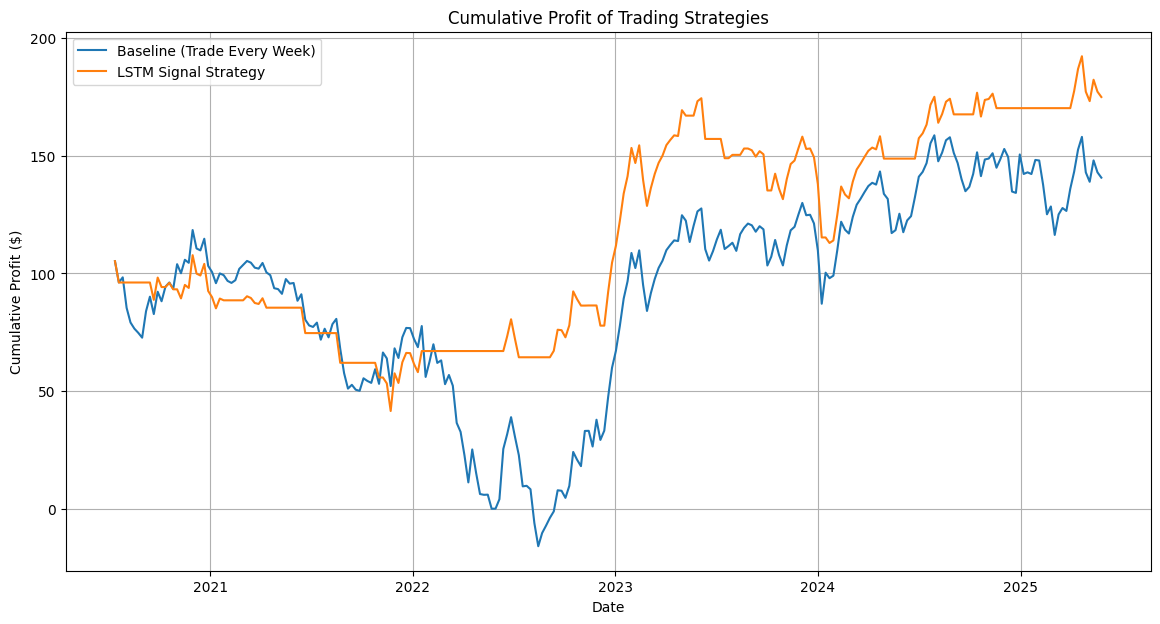

In [32]:
import matplotlib.pyplot as plt

test_aligned['Cumulative_Baseline'] = test_aligned['Profit_Baseline'].cumsum() + 100
test_aligned['Cumulative_Strategy'] = test_aligned['Profit_Strategy'].cumsum() + 100

plt.figure(figsize=(14, 7))
plt.plot(test_aligned['Date'], test_aligned['Cumulative_Baseline'], label='Baseline (Trade Every Week)')
plt.plot(test_aligned['Date'], test_aligned['Cumulative_Strategy'], label='LSTM Signal Strategy')
plt.xlabel('Date')
plt.ylabel('Cumulative Profit ($)')
plt.title('Cumulative Profit of Trading Strategies')
plt.legend()
plt.grid(True)
plt.show()

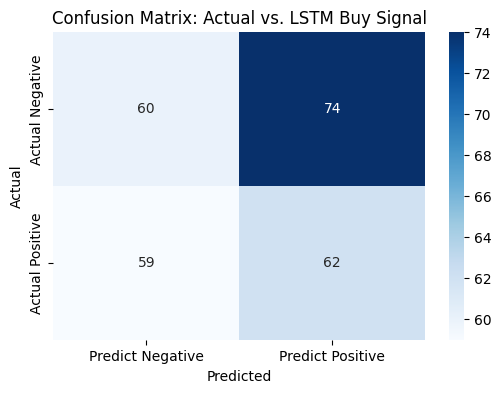

Confusion Matrix:
[[60 74]
 [59 62]]

Accuracy: 0.48
Precision (of positive predictions): 0.46
Recall (True Positive Rate): 0.51

Interpretation:
True Positives (TP): 62 - Correctly predicted a buy signal (Actual: Up, Predicted: Up)
True Negatives (TN): 60 - Correctly predicted no buy signal (Actual: Down, Predicted: Down)
False Positives (FP): 74 - Incorrectly predicted a buy signal (Actual: Down, Predicted: Up) - Type I error
False Negatives (FN): 59 - Incorrectly predicted no buy signal (Actual: Up, Predicted: Down) - Type II error

To evaluate if this is 'good', consider:
- Accuracy: Overall correct predictions.
- Precision: Out of all predicted buy signals, how many were actually up days.
- Recall: Out of all actual up days, how many were correctly identified.

The 'goodness' also depends on your trading strategy's risk tolerance and goals.


In [33]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

# Create actual labels based on whether Close is greater than Open
test_aligned['Actual_Signal'] = (test_aligned['Close'] > test_aligned['Open']).astype(int)

# The predicted signal is already in 'Buy_Signal' (True/False, convert to int 1/0)
test_aligned['Predicted_Signal'] = test_aligned['Buy_Signal'].astype(int)

# Generate the confusion matrix
cm = confusion_matrix(test_aligned['Actual_Signal'], test_aligned['Predicted_Signal'])

# Display the confusion matrix using a heatmap for better visualization
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predict Negative', 'Predict Positive'], yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Actual vs. LSTM Buy Signal')
plt.show()

# You can also print the raw confusion matrix
print("Confusion Matrix:")
print(cm)

# Calculate and print key metrics
accuracy = accuracy_score(test_aligned['Actual_Signal'], test_aligned['Predicted_Signal'])
precision = precision_score(test_aligned['Actual_Signal'], test_aligned['Predicted_Signal'])
recall = recall_score(test_aligned['Actual_Signal'], test_aligned['Predicted_Signal'])

print(f"\nAccuracy: {accuracy:.2f}")
print(f"Precision (of positive predictions): {precision:.2f}")
print(f"Recall (True Positive Rate): {recall:.2f}")

# Interpretation of the matrix
tn, fp, fn, tp = cm.ravel()

print("\nInterpretation:")
print(f"True Positives (TP): {tp} - Correctly predicted a buy signal (Actual: Up, Predicted: Up)")
print(f"True Negatives (TN): {tn} - Correctly predicted no buy signal (Actual: Down, Predicted: Down)")
print(f"False Positives (FP): {fp} - Incorrectly predicted a buy signal (Actual: Down, Predicted: Up) - Type I error")
print(f"False Negatives (FN): {fn} - Incorrectly predicted no buy signal (Actual: Up, Predicted: Down) - Type II error")

print("\nTo evaluate if this is 'good', consider:")
print("- Accuracy: Overall correct predictions.")
print("- Precision: Out of all predicted buy signals, how many were actually up days.")
print("- Recall: Out of all actual up days, how many were correctly identified.")
print("\nThe 'goodness' also depends on your trading strategy's risk tolerance and goals.")

In [34]:
# Calculate weekly returns for both strategies
test_aligned['Return_Baseline'] = test_aligned['Actual_Return']
test_aligned['Return_Strategy'] = test_aligned['Buy_Signal'].astype(int) * test_aligned['Actual_Return']

# Filter for weeks where the LSTM strategy traded
test_aligned_traded = test_aligned[test_aligned['Buy_Signal'] == True].copy()

# Calculate volatility (Standard Deviation / sqrt(52))
volatility_baseline = test_aligned['Return_Baseline'].std() / np.sqrt(52)
volatility_strategy = test_aligned_traded['Return_Strategy'].std() / np.sqrt(52) # Use filtered data here

# Calculate annual return (average weekly return * 52)
annual_return_baseline = test_aligned['Return_Baseline'].mean() * 52
annual_return_strategy = test_aligned_traded['Return_Strategy'].mean() * 52 # Use filtered data here

# Calculate Sharpe Ratio (Return / Volatility assuming risk-free rate is 0)
# Check for division by zero in case volatility_strategy is 0
sharpe_ratio_baseline = annual_return_baseline / volatility_baseline
sharpe_ratio_strategy = annual_return_strategy / volatility_strategy if volatility_strategy != 0 else float('nan')


# Display Returns
print("\nWeekly Returns:")
returns_summary = pd.DataFrame({
    'Strategy': ['Buy and Hold', 'LSTM Strategy (Traded Weeks)'],
    'Average Weekly Return': [test_aligned['Return_Baseline'].mean(), test_aligned_traded['Return_Strategy'].mean()]
})
display(returns_summary)

# Display Volatility
print("\nVolatility (Standard Deviation / sqrt(52)):")
volatility_summary = pd.DataFrame({
    'Strategy': ['Buy and Hold', 'LSTM Strategy (Traded Weeks)'],
    'Volatility': [volatility_baseline, volatility_strategy]
})
display(volatility_summary)

# Display Sharpe Ratio
print("\nSharpe Ratio (Annual Return / Volatility):")
sharpe_ratio_summary = pd.DataFrame({
    'Strategy': ['Buy and Hold', 'LSTM Strategy (Traded Weeks)'],
    'Sharpe Ratio': [sharpe_ratio_baseline, sharpe_ratio_strategy]
})
display(sharpe_ratio_summary)


Weekly Returns:


,Strategy,Average Weekly Return
0,Buy and Hold,-0.001596
1,LSTM Strategy (Traded Weeks),-0.005511



Volatility (Standard Deviation / sqrt(52)):


,Strategy,Volatility
0,Buy and Hold,0.010247
1,LSTM Strategy (Traded Weeks),0.010168



Sharpe Ratio (Annual Return / Volatility):


,Strategy,Sharpe Ratio
0,Buy and Hold,-8.098575
1,LSTM Strategy (Traded Weeks),-28.185193


In [35]:
# Optimize the predicted percentage change threshold to maximize Sharpe Ratio

best_sharpe_ratio = float('-inf')
best_threshold = None

# Define a range of thresholds to test (e.g., from -10% to +10% with a step)
# The distribution of Predicted_Percent_Change showed a wide range, so let's explore a reasonable range.
threshold_range = np.arange(-10.0, 10.1, 0.5)

print("Optimizing Predicted Percentage Change Threshold...")

for threshold in threshold_range:
    # Apply the threshold to generate buy signals
    test_aligned['Buy_Signal_Optimizer'] = test_aligned['Predicted_Percent_Change'] > threshold

    # Calculate returns for this threshold strategy
    test_aligned['Return_Strategy_Optimizer'] = test_aligned['Buy_Signal_Optimizer'].astype(int) * test_aligned['Actual_Return']

    # Filter for weeks where the strategy traded
    test_aligned_traded_optimizer = test_aligned[test_aligned['Buy_Signal_Optimizer'] == True].copy()

    # Calculate Sharpe Ratio
    if not test_aligned_traded_optimizer.empty:
        annual_return_optimizer = test_aligned_traded_optimizer['Return_Strategy_Optimizer'].mean() * 52
        volatility_optimizer = test_aligned_traded_optimizer['Return_Strategy_Optimizer'].std() / np.sqrt(52)

        # Calculate Sharpe Ratio, handling division by zero
        sharpe_ratio_optimizer = annual_return_optimizer / volatility_optimizer if volatility_optimizer != 0 else float('nan')

        # Check if this threshold gives a better Sharpe Ratio
        if not np.isnan(sharpe_ratio_optimizer) and sharpe_ratio_optimizer > best_sharpe_ratio:
            best_sharpe_ratio = sharpe_ratio_optimizer
            best_threshold = threshold

print(f"\nOptimization Complete.")
if best_threshold is not None:
    print(f"Best Predicted Percentage Change Threshold: {best_threshold:.2f}%")
    print(f"Corresponding Sharpe Ratio: {best_sharpe_ratio:.2f}")
else:
    print("Could not find a threshold that resulted in a valid Sharpe Ratio.")

# Store the best threshold for use in the evaluation cell
optimized_predicted_change_threshold = best_threshold

Optimizing Predicted Percentage Change Threshold...

Optimization Complete.
Best Predicted Percentage Change Threshold: -10.00%
Corresponding Sharpe Ratio: -3.66


In [42]:
# Display Maximum Drawdown from cell NCxkGTVeV3qT

# Assuming calculate_max_drawdown is defined
# We already calculated cumulative returns in the test_aligned DataFrame
baseline_cumulative_returns = test_aligned['Cumulative_Baseline'] / 100.0 # Convert back to a ratio
optimized_strategy_cumulative_returns = test_aligned['Cumulative_Strategy_Optimized'] / 100.0 # Convert back to a ratio


# Calculate Maximum Drawdown
max_drawdown_baseline = calculate_max_drawdown(baseline_cumulative_returns)
max_drawdown_optimized = calculate_max_drawdown(optimized_strategy_cumulative_returns)

print(f"Maximum Drawdown (Baseline - Buy and Hold): {max_drawdown_baseline:.2f}%")
print(f"Maximum Drawdown (LSTM Strategy - Optimized Threshold): {max_drawdown_optimized:.2f}%")

Maximum Drawdown (Baseline - Buy and Hold): -113.39%
Maximum Drawdown (LSTM Strategy - Optimized Threshold): -75.63%
